# HW14 — эмбеддинги, FAISS, оценка retrieval и mini-RAG

## Цель
Построить небольшой, но полностью воспроизводимый retrieval-пайплайн:
- создать и загрузить базу знаний;
- разбить документы на чанки;
- построить эмбеддинги;
- собрать индекс FAISS;
- оценить retrieval на контрольных запросах;
- сравнить две конфигурации чанкинга;
- обновить базу знаний и сравнить retrieval до/после;
- собрать простой mini-RAG с возвратом источников.

## Выбранная база знаний
В этой работе используется небольшая внутренняя база знаний учебной лаборатории по теме:
Python-окружение, Jupyter, embeddings, FAISS, retrieval, mini-RAG и требования к сдаче HW14.

## Почему это подходит
Тема единая, документы короткие, содержательные и воспроизводимые. 
По ним удобно задавать фактологические вопросы, сравнивать качество retrieval и показывать влияние обновления базы знаний.

In [1]:
from __future__ import annotations

import importlib.metadata as metadata
import json
import os
import random
import re
import sys
from pathlib import Path
from typing import Any, Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer

try:
    import faiss
except ImportError as e:
    raise ImportError(
        "Не найден пакет faiss"
    ) from e

try:
    import torch
except ImportError:
    torch = None

SEED = 42
TOP_K_CHUNKS = 5
TOP_K_SOURCES = 3

HW14_DIR = Path.cwd()
DATA_DIR = HW14_DIR / "data"
ARTIFACTS_DIR = HW14_DIR / "artifacts"

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

def get_version(package_name: str) -> str:
    try:
        return metadata.version(package_name)
    except Exception:
        return "not installed"

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

set_seed(SEED)

if torch is not None and torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print("Текущая папка:", HW14_DIR)
print("Python:", sys.version.split()[0])
print("numpy:", get_version("numpy"))
print("pandas:", get_version("pandas"))
print("matplotlib:", get_version("matplotlib"))
print("scikit-learn:", get_version("scikit-learn"))
print("faiss-cpu:", get_version("faiss-cpu"))
print("sentence-transformers:", get_version("sentence-transformers"))
print("torch:", get_version("torch"))
print("DEVICE:", DEVICE)
print("SEED:", SEED)

Текущая папка: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14
Python: 3.13.12
numpy: 2.4.1
pandas: 2.3.3
matplotlib: 3.10.7
scikit-learn: 1.8.0
faiss-cpu: 1.13.2
sentence-transformers: 5.3.0
torch: 2.10.0
DEVICE: cpu
SEED: 42


In [2]:
INITIAL_DOCUMENTS: List[Dict[str, str]] = [
    {
        "doc_id": "KB001",
        "category": "environment",
        "title": "Настройка Python-окружения",
        "text": (
            "В учебной лаборатории каждый проект запускают в отдельном виртуальном окружении. "
            "Сначала обновляют pip, затем устанавливают зависимости. Перед экспериментами фиксируют seed "
            "для random, numpy и torch, если torch используется. Это повышает воспроизводимость. "
            "Если GPU недоступен, ноутбук все равно должен корректно работать на CPU. "
            "В отчете обязательно указывают версии Python и ключевых библиотек."
        ),
    },
    {
        "doc_id": "KB002",
        "category": "git",
        "title": "Структура репозитория и Git",
        "text": (
            "Все домашние работы лежат внутри папки homeworks. Для HW14 нужна отдельная папка HW14 "
            "с ноутбуком, отчетом и подпапкой artifacts. Перед коммитом полезно проверить git status, "
            "убедиться, что временные файлы не попали в индекс, а итоговые csv сохранены под понятными именами. "
            "Нарушенная структура каталога усложняет проверку даже при корректном коде."
        ),
    },
    {
        "doc_id": "KB003",
        "category": "jupyter",
        "title": "Работа с Jupyter Notebook",
        "text": (
            "Ноутбук должен выполняться сверху вниз без ручных исправлений между ячейками. "
            "Перед сдачей нужно сделать Restart Kernel and Run All. "
            "Полезно делить ноутбук на блоки: импорт, загрузка данных, чанкинг, эмбеддинги, retrieval, "
            "evaluation, update и mini-RAG. В итоговой версии стоит показать несколько таблиц с результатами, "
            "а не только код."
        ),
    },
    {
        "doc_id": "KB004",
        "category": "data",
        "title": "Хранение базы знаний",
        "text": (
            "Базу знаний удобно хранить в json или csv, где у каждого документа есть doc_id, title, category и text. "
            "Для учебного retrieval достаточно 10-30 документов одной предметной области. "
            "Источник должен быть воспроизводимым: либо файлы лежат в репозитории, либо ноутбук явно создает их "
            "из зафиксированного списка. Смешивать документы разных тем нежелательно, потому что retrieval начнет "
            "возвращать шумный контекст."
        ),
    },
    {
        "doc_id": "KB005",
        "category": "embeddings",
        "title": "Эмбеддинги документов и запросов",
        "text": (
            "Dense retrieval строится на том, что документы и запросы переводятся в векторное пространство. "
            "Для русскоязычного корпуса удобно использовать sentence-transformers с мультиязычной моделью. "
            "После кодирования полезно нормализовать векторы. Тогда косинусное сходство можно считать "
            "через скалярное произведение, а запросы и чанки сравнивать в одной метрике."
        ),
    },
    {
        "doc_id": "KB006",
        "category": "faiss",
        "title": "Индекс FAISS",
        "text": (
            "Если векторы уже нормализованы, для базового поиска удобно использовать FAISS IndexFlatIP. "
            "Он возвращает top-k объектов с максимальным скалярным произведением. "
            "Для учебной домашней работы этого достаточно: не нужен внешний сервис, распределенная база "
            "или сложная настройка. Главное правильно подготовить эмбеддинги и добавить их в индекс."
        ),
    },
    {
        "doc_id": "KB007",
        "category": "metrics",
        "title": "Метрики качества retrieval",
        "text": (
            "Retrieval нельзя оценивать только на глаз по двум удачным примерам. "
            "Нужно подготовить контрольные запросы и заранее указать, какие документы считаются релевантными. "
            "В обязательной части считают хотя бы hit@k и recall@k. Дополнительно полезно считать MRR@k, "
            "потому что он показывает, насколько рано встретился первый релевантный источник."
        ),
    },
    {
        "doc_id": "KB008",
        "category": "chunking",
        "title": "Чанкинг документов",
        "text": (
            "Перед построением индекса длинные документы разбивают на чанки. "
            "Слишком крупные фрагменты смешивают несколько смыслов, а слишком мелкие теряют контекст. "
            "Overlap помогает не разрывать важные переходы между соседними частями текста. "
            "В учебном проекте достаточно одного воспроизводимого способа чанкинга по словам, "
            "но параметры chunk_size и overlap нужно явно объяснить и сравнить хотя бы в одном эксперименте."
        ),
    },
    {
        "doc_id": "KB009",
        "category": "rag",
        "title": "Как устроен mini-RAG",
        "text": (
            "Базовый mini-RAG состоит из нескольких шагов: пользователь задает вопрос, retriever ищет top-k "
            "релевантных фрагментов, затем эти фрагменты объединяются в контекст, а поверх контекста формируется ответ. "
            "Даже простой extractive генератор уже показывает идею RAG. Если retrieval ошибся, генерация тоже обычно страдает."
        ),
    },
    {
        "doc_id": "KB010",
        "category": "submission",
        "title": "Артефакты и отчет",
        "text": (
            "В artifacts обязательно сохраняют retrieval_eval.csv, rag_examples.csv и retrieval_before_after_update.csv. "
            "В retrieval_eval.csv должны быть query, expected_source, retrieved_sources и hit_at_k. "
            "В отчете нужно дать ссылки на файлы из artifacts и кратко описать, что показали retrieval, "
            "обновление базы знаний и mini-RAG. Названия разделов в report.md менять нельзя."
        ),
    },
    {
        "doc_id": "KB011",
        "category": "analysis",
        "title": "Типовые ошибки и диагностика",
        "text": (
            "Если mini-RAG отвечает плохо, сначала нужно проверить retrieval, а не винить генератор. "
            "Часто релевантный источник вообще не попадает в retrieved context из-за плохого чанкинга, "
            "маленького top-k или слабой формулировки запроса. Поэтому в анализе ошибок важно разделять "
            "сбой retrieval и сбой генерации."
        ),
    },
    {
        "doc_id": "KB012",
        "category": "sources",
        "title": "Возврат источников в ответе",
        "text": (
            "В финальном mini-RAG желательно возвращать короткий ответ и список источников в формате doc_id или title. "
            "Это делает пайплайн прозрачнее и упрощает проверку. Если по найденному контексту нельзя уверенно ответить, "
            "система должна прямо сказать об этом вместо уверенного выдумывания. "
            "Для учебной работы честная неопределенность лучше галлюцинации."
        ),
    },
]

UPDATE_DOCUMENTS: List[Dict[str, str]] = [
    {
        "doc_id": "KB013",
        "category": "models",
        "title": "Кэширование моделей sentence-transformers",
        "text": (
            "При первом запуске sentence-transformers модель загружается в локальный кэш. "
            "На Windows кэш обычно находится внутри профиля пользователя, если путь не переопределен переменными среды. "
            "При нестабильном интернете модель лучше скачать один раз и затем использовать повторно из кэша. "
            "Эта информация особенно полезна для воспроизводимости и повторного запуска ноутбука."
        ),
    },
    {
        "doc_id": "KB014",
        "category": "generation",
        "title": "Ограничения шаблонного генератора",
        "text": (
            "Если в учебном mini-RAG используется extractive или шаблонный генератор, он плохо перефразирует текст "
            "и редко делает сложные логические выводы. Такой подход хорошо подходит для демонстрации пайплайна, "
            "но ответы могут быть сухими. При конфликте между источниками шаблонный генератор обычно не умеет "
            "разрешать противоречия и просто выбирает наиболее похожие фрагменты."
        ),
    },
    {
        "doc_id": "KB015",
        "category": "hardware",
        "title": "Политика использования CPU и GPU",
        "text": (
            "Для HW14 достаточно CPU, если корпус небольшой и используется компактная embedding-модель. "
            "GPU можно применять для ускорения, но он не является обязательным требованием зачета. "
            "Важно, чтобы ноутбук корректно работал и на машине без CUDA. "
            "В ноутбуке и отчете желательно явно печатать выбранное устройство выполнения."
        ),
    },
]

INITIAL_PATH = DATA_DIR / "knowledge_base_initial.json"
UPDATE_PATH = DATA_DIR / "knowledge_base_update.json"

INITIAL_PATH.write_text(
    json.dumps(INITIAL_DOCUMENTS, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
UPDATE_PATH.write_text(
    json.dumps(UPDATE_DOCUMENTS, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Созданы файлы:")
print("-", INITIAL_PATH)
print("-", UPDATE_PATH)

Созданы файлы:
- C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14\data\knowledge_base_initial.json
- C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14\data\knowledge_base_update.json


In [3]:
def load_documents(path: Path) -> List[Dict[str, str]]:
    return json.loads(path.read_text(encoding="utf-8"))

initial_docs = load_documents(INITIAL_PATH)
update_docs = load_documents(UPDATE_PATH)
all_updated_docs = initial_docs + update_docs

print("Число исходных документов:", len(initial_docs))
print("Число документов после обновления:", len(all_updated_docs))

docs_df = pd.DataFrame(initial_docs)
display(docs_df[["doc_id", "category", "title"]])

display(Markdown("### Примеры документов"))
display(docs_df[["doc_id", "title", "text"]].head(4))

Число исходных документов: 12
Число документов после обновления: 15


,doc_id,category,title
0,KB001,environment,Настройка Python-окружения
1,KB002,git,Структура репозитория и Git
2,KB003,jupyter,Работа с Jupyter Notebook
3,KB004,data,Хранение базы знаний
4,KB005,embeddings,Эмбеддинги документов и запросов
5,KB006,faiss,Индекс FAISS
6,KB007,metrics,Метрики качества retrieval
7,KB008,chunking,Чанкинг документов
8,KB009,rag,Как устроен mini-RAG
9,KB010,submission,Артефакты и отчет


### Примеры документов

,doc_id,title,text
0,KB001,Настройка Python-окружения,В учебной лаборатории каждый проект запускают ...
1,KB002,Структура репозитория и Git,Все домашние работы лежат внутри папки homewor...
2,KB003,Работа с Jupyter Notebook,Ноутбук должен выполняться сверху вниз без руч...
3,KB004,Хранение базы знаний,"Базу знаний удобно хранить в json или csv, где..."


## Чанкинг документов
Ниже используется простой воспроизводимый чанкинг по словам.
Базовая идея:
- чистим текст от лишних пробелов;
- делим на фрагменты по `chunk_size`;
- добавляем `overlap`, чтобы не терять переходы между соседними частями.

In [4]:
def normalize_text(text: str) -> str:
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def chunk_text(text: str, chunk_size: int = 35, overlap: int = 8) -> List[str]:
    words = normalize_text(text).split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    step = chunk_size - overlap
    chunks: List[str] = []

    for start in range(0, len(words), step):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            continue

        chunks.append(" ".join(chunk_words))

        if start + chunk_size >= len(words):
            break

    return chunks

def build_chunks_dataframe(
    documents: List[Dict[str, str]],
    chunk_size: int = 35,
    overlap: int = 8,
) -> pd.DataFrame:
    rows = []

    for doc in documents:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk in enumerate(chunks):
            rows.append(
                {
                    "source_id": doc["doc_id"],
                    "title": doc["title"],
                    "category": doc["category"],
                    "chunk_id": chunk_id,
                    "chunk_text": chunk,
                    "n_words": len(chunk.split()),
                }
            )

    return pd.DataFrame(rows)

BASE_CHUNK_SIZE = 35
BASE_OVERLAP = 8

chunks_df = build_chunks_dataframe(
    initial_docs,
    chunk_size=BASE_CHUNK_SIZE,
    overlap=BASE_OVERLAP,
)

print("Число чанков:", len(chunks_df))
display(chunks_df.head(10))

display(Markdown("### Как один документ превращается в чанки"))
example_doc_id = "KB008"
display(
    chunks_df.loc[chunks_df["source_id"] == example_doc_id, ["source_id", "chunk_id", "chunk_text"]]
)

chunk_examples_path = ARTIFACTS_DIR / "chunk_examples.csv"
chunks_df.head(20).to_csv(chunk_examples_path, index=False, encoding="utf-8-sig")
print("Дополнительный файл с примерами чанков сохранен:", chunk_examples_path)

Число чанков: 24


,source_id,title,category,chunk_id,chunk_text,n_words
0,KB001,Настройка Python-окружения,environment,0,В учебной лаборатории каждый проект запускают ...,35
1,KB001,Настройка Python-окружения,environment,1,используется. Это повышает воспроизводимость. ...,24
2,KB002,Структура репозитория и Git,git,0,Все домашние работы лежат внутри папки homewor...,35
3,KB002,Структура репозитория и Git,git,1,"временные файлы не попали в индекс, а итоговые...",22
4,KB003,Работа с Jupyter Notebook,jupyter,0,Ноутбук должен выполняться сверху вниз без руч...,35
5,KB003,Работа с Jupyter Notebook,jupyter,1,"чанкинг, эмбеддинги, retrieval, evaluation, up...",20
6,KB004,Хранение базы знаний,data,0,"Базу знаний удобно хранить в json или csv, где...",35
7,KB004,Хранение базы знаний,data,1,Источник должен быть воспроизводимым: либо фай...,29
8,KB005,Эмбеддинги документов и запросов,embeddings,0,"Dense retrieval строится на том, что документы...",35
9,KB005,Эмбеддинги документов и запросов,embeddings,1,Тогда косинусное сходство можно считать через ...,16


### Как один документ превращается в чанки

,source_id,chunk_id,chunk_text
14,KB008,0,Перед построением индекса длинные документы ра...
15,KB008,1,частями текста. В учебном проекте достаточно о...


Дополнительный файл с примерами чанков сохранен: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14\artifacts\chunk_examples.csv


In [5]:
class EmbeddingBackend:
    backend_name: str = "base"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return (vectors / norms).astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return (vectors / norms).astype("float32")


def build_embedding_backend(
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device: str = "cpu",
) -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(model_name=model_name, device=device)
        print("Используем полноценные dense embeddings.")
        print("Бэкэнд:", backend.backend_name)
        return backend
    except Exception as e:
        print("Не удалось загрузить sentence-transformers encoder.")
        print("Причина:", repr(e))
        print("Переключаемся на TF-IDF fallback. Но лучше исправить окружение и перезапустить ноутбук.")
        return TfidfFallbackBackend()


def build_faiss_index(vectors: np.ndarray) -> faiss.IndexFlatIP:
    index = faiss.IndexFlatIP(vectors.shape[1])
    index.add(vectors.astype("float32"))
    return index


def retrieve_chunks(
    query: str,
    embedder: EmbeddingBackend,
    index: faiss.IndexFlatIP,
    chunks_df: pd.DataFrame,
    top_k_chunks: int = 5,
) -> pd.DataFrame:
    query_vector = embedder.encode_queries([query]).astype("float32")
    scores, indices = index.search(query_vector, top_k_chunks)

    result_df = chunks_df.iloc[indices[0]].copy().reset_index(drop=True)
    result_df["score"] = scores[0]
    result_df.insert(0, "rank", range(1, len(result_df) + 1))
    return result_df


def deduplicate_sources(
    result_df: pd.DataFrame,
    top_k_sources: int = 3,
) -> List[Dict[str, Any]]:
    unique_rows: List[Dict[str, Any]] = []
    seen = set()

    sorted_df = result_df.sort_values(["score", "rank"], ascending=[False, True])

    for _, row in sorted_df.iterrows():
        source_id = row["source_id"]
        if source_id in seen:
            continue

        seen.add(source_id)
        unique_rows.append(
            {
                "source_id": source_id,
                "title": row["title"],
                "score": float(row["score"]),
                "chunk_id": int(row["chunk_id"]),
                "chunk_text": row["chunk_text"],
            }
        )

        if len(unique_rows) >= top_k_sources:
            break

    return unique_rows


def build_retriever(
    documents: List[Dict[str, str]],
    chunk_size: int,
    overlap: int,
    model_name: str,
    device: str = "cpu",
) -> Dict[str, Any]:
    chunks_df = build_chunks_dataframe(documents, chunk_size=chunk_size, overlap=overlap)
    embedder = build_embedding_backend(model_name=model_name, device=device)
    chunk_vectors = embedder.fit_documents(chunks_df["chunk_text"].tolist())
    index = build_faiss_index(chunk_vectors)

    return {
        "documents": documents,
        "chunks_df": chunks_df,
        "embedder": embedder,
        "chunk_vectors": chunk_vectors,
        "index": index,
        "chunk_size": chunk_size,
        "overlap": overlap,
        "model_name": model_name,
        "device": device,
    }


def retrieve_sources(
    query: str,
    retriever: Dict[str, Any],
    top_k_chunks: int = 5,
    top_k_sources: int = 3,
) -> List[Dict[str, Any]]:
    chunk_results = retrieve_chunks(
        query=query,
        embedder=retriever["embedder"],
        index=retriever["index"],
        chunks_df=retriever["chunks_df"],
        top_k_chunks=top_k_chunks,
    )
    return deduplicate_sources(chunk_results, top_k_sources=top_k_sources)

In [6]:
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

initial_retriever = build_retriever(
    documents=initial_docs,
    chunk_size=BASE_CHUNK_SIZE,
    overlap=BASE_OVERLAP,
    model_name=MODEL_NAME,
    device=DEVICE,
)

print("Размер матрицы эмбеддингов:", initial_retriever["chunk_vectors"].shape)

vector_norms = np.linalg.norm(initial_retriever["chunk_vectors"], axis=1)
print("Минимальная норма:", round(float(vector_norms.min()), 4))
print("Максимальная норма:", round(float(vector_norms.max()), 4))
print("Средняя норма:", round(float(vector_norms.mean()), 4))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Размер матрицы эмбеддингов: (24, 384)
Минимальная норма: 1.0
Максимальная норма: 1.0
Средняя норма: 1.0


In [7]:
sample_queries = [
    "Какие метрики retrieval обязательны в HW14?",
    "Зачем нужен overlap при чанкинге?",
    "Какой индекс FAISS подходит для нормализованных векторов?",
    "Почему в mini-RAG важно возвращать источники?",
    "Что должно лежать в папке artifacts?",
]

for query in sample_queries:
    print("=" * 100)
    print("ЗАПРОС:", query)
    chunk_results = retrieve_chunks(
        query=query,
        embedder=initial_retriever["embedder"],
        index=initial_retriever["index"],
        chunks_df=initial_retriever["chunks_df"],
        top_k_chunks=TOP_K_CHUNKS,
    )
    display(chunk_results[["rank", "source_id", "title", "chunk_id", "score", "chunk_text"]])

    unique_sources = retrieve_sources(
        query=query,
        retriever=initial_retriever,
        top_k_chunks=TOP_K_CHUNKS,
        top_k_sources=TOP_K_SOURCES,
    )
    print("Уникальные источники:", [item["source_id"] for item in unique_sources])

ЗАПРОС: Какие метрики retrieval обязательны в HW14?


,rank,source_id,title,chunk_id,score,chunk_text
0,1,KB007,Метрики качества retrieval,0,0.551535,Retrieval нельзя оценивать только на глаз по д...
1,2,KB002,Структура репозитория и Git,0,0.479463,Все домашние работы лежат внутри папки homewor...
2,3,KB005,Эмбеддинги документов и запросов,1,0.460360,Тогда косинусное сходство можно считать через ...
3,4,KB011,Типовые ошибки и диагностика,0,0.445149,"Если mini-RAG отвечает плохо, сначала нужно пр..."
4,5,KB004,Хранение базы знаний,0,0.408918,"Базу знаний удобно хранить в json или csv, где..."


Уникальные источники: ['KB007', 'KB002', 'KB005']
ЗАПРОС: Зачем нужен overlap при чанкинге?


,rank,source_id,title,chunk_id,score,chunk_text
0,1,KB008,Чанкинг документов,1,0.537231,частями текста. В учебном проекте достаточно о...
1,2,KB008,Чанкинг документов,0,0.524341,Перед построением индекса длинные документы ра...
2,3,KB005,Эмбеддинги документов и запросов,1,0.379094,Тогда косинусное сходство можно считать через ...
3,4,KB009,Как устроен mini-RAG,0,0.312762,Базовый mini-RAG состоит из нескольких шагов: ...
4,5,KB011,Типовые ошибки и диагностика,0,0.308233,"Если mini-RAG отвечает плохо, сначала нужно пр..."


Уникальные источники: ['KB008', 'KB005', 'KB009']
ЗАПРОС: Какой индекс FAISS подходит для нормализованных векторов?


...

Уникальные источники: ['KB006', 'KB005', 'KB004']
ЗАПРОС: Почему в mini-RAG важно возвращать источники?


,rank,source_id,title,chunk_id,score,chunk_text
0,1,KB011,Типовые ошибки и диагностика,0,0.704365,"Если mini-RAG отвечает плохо, сначала нужно пр..."
1,2,KB012,Возврат источников в ответе,0,0.648749,В финальном mini-RAG желательно возвращать кор...
2,3,KB004,Хранение базы знаний,1,0.577126,Источник должен быть воспроизводимым: либо фай...
3,4,KB010,Артефакты и отчет,1,0.543024,"кратко описать, что показали retrieval, обновл..."
4,5,KB009,Как устроен mini-RAG,0,0.493061,Базовый mini-RAG состоит из нескольких шагов: ...


Уникальные источники: ['KB011', 'KB012', 'KB004']
ЗАПРОС: Что должно лежать в папке artifacts?


,rank,source_id,title,chunk_id,score,chunk_text
0,1,KB010,Артефакты и отчет,0,0.613425,В artifacts обязательно сохраняют retrieval_ev...
1,2,KB004,Хранение базы знаний,1,0.510735,Источник должен быть воспроизводимым: либо фай...
2,3,KB002,Структура репозитория и Git,0,0.428759,Все домашние работы лежат внутри папки homewor...
3,4,KB008,Чанкинг документов,0,0.382926,Перед построением индекса длинные документы ра...
4,5,KB004,Хранение базы знаний,0,0.344017,"Базу знаний удобно хранить в json или csv, где..."


Уникальные источники: ['KB010', 'KB004', 'KB002']


## Контрольные запросы и оценка retrieval
Ниже готовится маленький benchmark:
- 10 контрольных запросов;
- для каждого запроса указаны релевантные документы;
- считаются hit@k, recall@k и дополнительно MRR@k.

In [8]:
BENCHMARK_QUERIES: List[Dict[str, Any]] = [
    {
        "query": "Какие метрики retrieval обязательны в HW14?",
        "relevant_doc_ids": ["KB007"],
    },
    {
        "query": "Зачем нужен overlap при чанкинге документов?",
        "relevant_doc_ids": ["KB008"],
    },
    {
        "query": "Какой индекс FAISS подходит для нормализованных векторов?",
        "relevant_doc_ids": ["KB006"],
    },
    {
        "query": "Что должно лежать в папке artifacts?",
        "relevant_doc_ids": ["KB010"],
    },
    {
        "query": "Почему mini-RAG должен возвращать источники?",
        "relevant_doc_ids": ["KB009", "KB012"],
    },
    {
        "query": "Как проверить ноутбук перед сдачей?",
        "relevant_doc_ids": ["KB003"],
    },
    {
        "query": "Как лучше хранить исходную базу знаний?",
        "relevant_doc_ids": ["KB004"],
    },
    {
        "query": "Зачем фиксировать seed в экспериментах?",
        "relevant_doc_ids": ["KB001"],
    },
    {
        "query": "Почему в анализе важно разделять ошибки retrieval и генерации?",
        "relevant_doc_ids": ["KB011", "KB009"],
    },
    {
        "query": "Где должна лежать папка HW14 в репозитории?",
        "relevant_doc_ids": ["KB002"],
    },
]

def evaluate_retrieval(
    benchmark_queries: List[Dict[str, Any]],
    retriever: Dict[str, Any],
    top_k_chunks: int = 5,
    top_k_sources: int = 3,
) -> tuple[pd.DataFrame, Dict[str, float]]:
    rows = []

    for item in benchmark_queries:
        results = retrieve_sources(
            query=item["query"],
            retriever=retriever,
            top_k_chunks=top_k_chunks,
            top_k_sources=top_k_sources,
        )

        retrieved_source_ids = [x["source_id"] for x in results]
        relevant_source_ids = item["relevant_doc_ids"]

        n_relevant_found = len(set(retrieved_source_ids) & set(relevant_source_ids))
        hit_at_k = int(n_relevant_found > 0)
        recall_at_k = n_relevant_found / len(set(relevant_source_ids))

        rank_of_first_relevant = None
        for rank, source_id in enumerate(retrieved_source_ids, start=1):
            if source_id in relevant_source_ids:
                rank_of_first_relevant = rank
                break

        mrr_at_k = 0.0 if rank_of_first_relevant is None else 1.0 / rank_of_first_relevant

        rows.append(
            {
                "query": item["query"],
                "expected_source": " | ".join(relevant_source_ids),
                "retrieved_sources": " | ".join(retrieved_source_ids),
                "hit_at_k": hit_at_k,
                "recall_at_k": round(recall_at_k, 4),
                "rank_of_first_relevant": rank_of_first_relevant,
                "mrr_at_k": round(mrr_at_k, 4),
            }
        )

    eval_df = pd.DataFrame(rows)
    summary = {
        "hit_at_k": round(float(eval_df["hit_at_k"].mean()), 4),
        "recall_at_k": round(float(eval_df["recall_at_k"].mean()), 4),
        "mrr_at_k": round(float(eval_df["mrr_at_k"].mean()), 4),
    }
    return eval_df, summary

retrieval_eval_df, retrieval_summary = evaluate_retrieval(
    benchmark_queries=BENCHMARK_QUERIES,
    retriever=initial_retriever,
    top_k_chunks=TOP_K_CHUNKS,
    top_k_sources=TOP_K_SOURCES,
)

display(retrieval_eval_df)

print("Итоговые метрики:")
for metric_name, metric_value in retrieval_summary.items():
    print(f"{metric_name}: {metric_value}")

retrieval_eval_path = ARTIFACTS_DIR / "retrieval_eval.csv"
retrieval_eval_df.to_csv(retrieval_eval_path, index=False, encoding="utf-8-sig")
print("Сохранен файл:", retrieval_eval_path)

,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant,mrr_at_k
0,Какие метрики retrieval обязательны в HW14?,KB007,KB007 | KB002 | KB005,1,1.0,1,1.0
1,Зачем нужен overlap при чанкинге документов?,KB008,KB008 | KB004 | KB007,1,1.0,1,1.0
2,Какой индекс FAISS подходит для нормализованны...,KB006,KB006 | KB005 | KB004,1,1.0,1,1.0
3,Что должно лежать в папке artifacts?,KB010,KB010 | KB004 | KB002,1,1.0,1,1.0
4,Почему mini-RAG должен возвращать источники?,KB009 | KB012,KB011 | KB012 | KB004,1,0.5,2,0.5
5,Как проверить ноутбук перед сдачей?,KB003,KB003 | KB001 | KB002,1,1.0,1,1.0
6,Как лучше хранить исходную базу знаний?,KB004,KB004 | KB006 | KB007,1,1.0,1,1.0
7,Зачем фиксировать seed в экспериментах?,KB001,KB001 | KB008 | KB009,1,1.0,1,1.0
8,Почему в анализе важно разделять ошибки retrie...,KB011 | KB009,KB011 | KB009 | KB007,1,1.0,1,1.0
9,Где должна лежать папка HW14 в репозитории?,KB002,KB002 | KB004 | KB007,1,1.0,1,1.0


Итоговые метрики:
hit_at_k: 1.0
recall_at_k: 0.95
mrr_at_k: 0.95
Сохранен файл: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14\artifacts\retrieval_eval.csv


## Сравнение двух конфигураций чанкинга
Делаем один обязательный сравнительный эксперимент.
Сравниваем:
- вариант 1: `chunk_size=35`, `overlap=8`
- вариант 2: `chunk_size=55`, `overlap=12`

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


,config_label,chunk_size,overlap,n_chunks,hit_at_k,recall_at_k,mrr_at_k
0,"chunk=55, overlap=12",55,12,13,1.0,1.00,0.95
1,"chunk=35, overlap=8",35,8,24,1.0,0.95,0.95


Лучшая конфигурация: {'config_label': 'chunk=55, overlap=12', 'chunk_size': 55, 'overlap': 12, 'n_chunks': 13, 'hit_at_k': 1.0, 'recall_at_k': 1.0, 'mrr_at_k': 0.95}


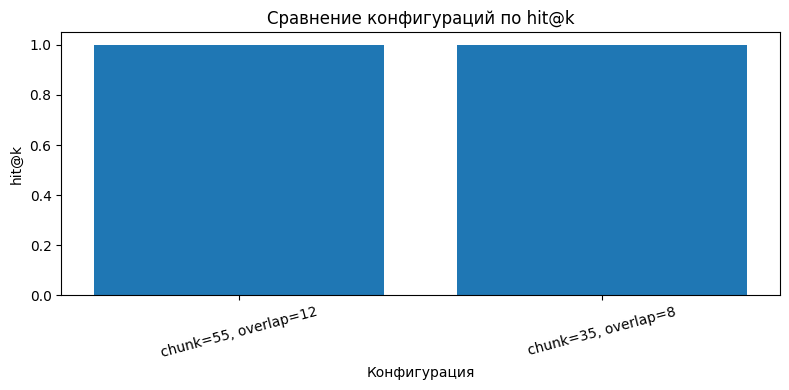

In [9]:
CONFIGS = [
    {"chunk_size": 35, "overlap": 8},
    {"chunk_size": 55, "overlap": 12},
]

config_rows = []

for cfg in CONFIGS:
    cfg_retriever = build_retriever(
        documents=initial_docs,
        chunk_size=cfg["chunk_size"],
        overlap=cfg["overlap"],
        model_name=MODEL_NAME,
        device=DEVICE,
    )

    cfg_eval_df, cfg_summary = evaluate_retrieval(
        benchmark_queries=BENCHMARK_QUERIES,
        retriever=cfg_retriever,
        top_k_chunks=TOP_K_CHUNKS,
        top_k_sources=TOP_K_SOURCES,
    )

    config_rows.append(
        {
            "config_label": f"chunk={cfg['chunk_size']}, overlap={cfg['overlap']}",
            "chunk_size": cfg["chunk_size"],
            "overlap": cfg["overlap"],
            "n_chunks": len(cfg_retriever["chunks_df"]),
            "hit_at_k": cfg_summary["hit_at_k"],
            "recall_at_k": cfg_summary["recall_at_k"],
            "mrr_at_k": cfg_summary["mrr_at_k"],
        }
    )

config_compare_df = pd.DataFrame(config_rows).sort_values(
    ["hit_at_k", "recall_at_k", "mrr_at_k"],
    ascending=[False, False, False],
).reset_index(drop=True)

display(config_compare_df)

best_config = config_compare_df.iloc[0].to_dict()
print("Лучшая конфигурация:", best_config)

plt.figure(figsize=(8, 4))
plt.bar(config_compare_df["config_label"], config_compare_df["hit_at_k"])
plt.title("Сравнение конфигураций по hit@k")
plt.xlabel("Конфигурация")
plt.ylabel("hit@k")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Обновление базы знаний и переиндексация
Теперь добавим 3 новых документа, затем переиндексируем корпус и сравним retrieval до и после обновления.

In [10]:
best_chunk_size = int(best_config["chunk_size"])
best_overlap = int(best_config["overlap"])

retriever_before_update = build_retriever(
    documents=initial_docs,
    chunk_size=best_chunk_size,
    overlap=best_overlap,
    model_name=MODEL_NAME,
    device=DEVICE,
)

retriever_after_update = build_retriever(
    documents=all_updated_docs,
    chunk_size=best_chunk_size,
    overlap=best_overlap,
    model_name=MODEL_NAME,
    device=DEVICE,
)

UPDATE_EFFECT_QUERIES = [
    "Где обычно хранится кэш моделей sentence-transformers на Windows?",
    "Почему шаблонный генератор в mini-RAG может отвечать сухо?",
    "Нужен ли GPU для зачета HW14?",
    "Что обязательно нужно сохранить в artifacts?",
]

before_after_rows = []

for query in UPDATE_EFFECT_QUERIES:
    before_sources = [
        x["source_id"]
        for x in retrieve_sources(
            query=query,
            retriever=retriever_before_update,
            top_k_chunks=TOP_K_CHUNKS,
            top_k_sources=TOP_K_SOURCES,
        )
    ]
    after_sources = [
        x["source_id"]
        for x in retrieve_sources(
            query=query,
            retriever=retriever_after_update,
            top_k_chunks=TOP_K_CHUNKS,
            top_k_sources=TOP_K_SOURCES,
        )
    ]

    before_after_rows.append(
        {
            "query": query,
            "before_retrieved_sources": " | ".join(before_sources),
            "after_retrieved_sources": " | ".join(after_sources),
            "changed": before_sources != after_sources,
        }
    )

before_after_df = pd.DataFrame(before_after_rows)
display(before_after_df)

before_after_path = ARTIFACTS_DIR / "retrieval_before_after_update.csv"
before_after_df.to_csv(before_after_path, index=False, encoding="utf-8-sig")
print("Сохранен файл:", before_after_path)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Где обычно хранится кэш моделей sentence-trans...,KB005 | KB009 | KB012,KB013 | KB005 | KB009,True
1,Почему шаблонный генератор в mini-RAG может от...,KB011 | KB009 | KB001,KB014 | KB011 | KB009,True
2,Нужен ли GPU для зачета HW14?,KB002 | KB001 | KB003,KB015 | KB002 | KB001,True
3,Что обязательно нужно сохранить в artifacts?,KB010 | KB008 | KB002,KB010 | KB008 | KB002,False


Сохранен файл: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14\artifacts\retrieval_before_after_update.csv


## Mini-RAG
В этой версии используется простой extractive generator:
- retriever ищет top-k чанков;
- из найденных чанков собирается контекст;
- из контекста выбираются наиболее релевантные предложения;
- ответ возвращается вместе с источниками.

In [11]:
STOPWORDS = {
    "и", "в", "во", "на", "по", "с", "со", "что", "это", "как", "для", "не", "но", "или",
    "а", "к", "ко", "из", "за", "под", "над", "у", "о", "об", "от", "до", "ли", "же",
    "то", "так", "при", "если", "нужно", "нужен", "нужна", "нужны", "можно", "где",
    "почему", "какой", "какая", "какие", "когда", "зачем"
}

def tokenize_for_scoring(text: str) -> List[str]:
    tokens = re.findall(r"[a-zA-Zа-яА-ЯёЁ0-9@_-]+", text.lower())
    return [tok for tok in tokens if tok not in STOPWORDS]

def split_sentences(text: str) -> List[str]:
    text = normalize_text(text)
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [sent.strip() for sent in sentences if sent.strip()]

def build_context_from_chunks(chunk_results_df: pd.DataFrame, max_chunks: int = 4) -> str:
    selected = chunk_results_df.head(max_chunks)
    context_parts = []
    for _, row in selected.iterrows():
        context_parts.append(f"[{row['source_id']}] {row['chunk_text']}")
    return "\n".join(context_parts)

def generate_extractive_answer(question: str, chunk_results_df: pd.DataFrame) -> str:
    question_tokens = set(tokenize_for_scoring(question))
    candidate_sentences = []

    for _, row in chunk_results_df.iterrows():
        row_score = float(row["score"])
        row_source = row["source_id"]

        for sentence in split_sentences(row["chunk_text"]):
            sentence_tokens = set(tokenize_for_scoring(sentence))
            overlap = len(question_tokens & sentence_tokens)

            if overlap == 0:
                continue

            score = overlap + row_score
            candidate_sentences.append(
                {
                    "score": score,
                    "sentence": sentence,
                    "source_id": row_source,
                }
            )

    if not candidate_sentences:
        return (
            "В найденном контексте нет достаточно явного ответа на вопрос. "
            "Нужно либо расширить базу знаний, либо улучшить retrieval."
        )

    candidate_df = (
        pd.DataFrame(candidate_sentences)
        .sort_values("score", ascending=False)
        .drop_duplicates(subset=["sentence"])
        .head(2)
    )

    answer = " ".join(candidate_df["sentence"].tolist())
    return answer

def ask_mini_rag(
    question: str,
    retriever: Dict[str, Any],
    top_k_chunks: int = 4,
    top_k_sources: int = 3,
) -> Dict[str, Any]:
    chunk_results = retrieve_chunks(
        query=question,
        embedder=retriever["embedder"],
        index=retriever["index"],
        chunks_df=retriever["chunks_df"],
        top_k_chunks=top_k_chunks,
    )

    unique_sources = deduplicate_sources(chunk_results, top_k_sources=top_k_sources)
    answer = generate_extractive_answer(question, chunk_results.head(top_k_chunks))
    context = build_context_from_chunks(chunk_results, max_chunks=top_k_chunks)

    return {
        "question": question,
        "answer": answer,
        "retrieved_sources": [item["source_id"] for item in unique_sources],
        "context": context,
    }

final_retriever = retriever_after_update

In [12]:
RAG_QUESTIONS = [
    "Зачем нужен overlap при чанкинге?",
    "Какой индекс используется для базового FAISS-поиска?",
    "Где обычно хранится кэш моделей sentence-transformers на Windows?",
    "Нужен ли GPU для зачета HW14?",
    "Почему mini-RAG должен возвращать источники?",
]

rag_rows = []

for question in RAG_QUESTIONS:
    result = ask_mini_rag(
        question=question,
        retriever=final_retriever,
        top_k_chunks=4,
        top_k_sources=3,
    )
    rag_rows.append(
        {
            "question": result["question"],
            "answer": result["answer"],
            "retrieved_sources": " | ".join(result["retrieved_sources"]),
        }
    )

    print("=" * 100)
    print("ВОПРОС:", result["question"])
    print("ОТВЕТ:", result["answer"])
    print("ИСТОЧНИКИ:", result["retrieved_sources"])
    print("КОНТЕКСТ:")
    print(result["context"])

rag_examples_df = pd.DataFrame(rag_rows)
display(rag_examples_df)

rag_examples_path = ARTIFACTS_DIR / "rag_examples.csv"
rag_examples_df.to_csv(rag_examples_path, index=False, encoding="utf-8-sig")
print("Сохранен файл:", rag_examples_path)

ВОПРОС: Зачем нужен overlap при чанкинге?
ОТВЕТ: Overlap помогает не разрывать важные переходы между соседними частями текста. В учебном проекте достаточно одного воспроизводимого способа чанкинга по словам, но параметры chunk_size и overlap нужно явно объяснить и сравнить хотя бы в одном эксперименте.
ИСТОЧНИКИ: ['KB008', 'KB014', 'KB009']
КОНТЕКСТ:
[KB008] Перед построением индекса длинные документы разбивают на чанки. Слишком крупные фрагменты смешивают несколько смыслов, а слишком мелкие теряют контекст. Overlap помогает не разрывать важные переходы между соседними частями текста. В учебном проекте достаточно одного воспроизводимого способа чанкинга по словам, но параметры chunk_size и overlap нужно явно объяснить и сравнить хотя бы в одном эксперименте.
[KB014] Если в учебном mini-RAG используется extractive или шаблонный генератор, он плохо перефразирует текст и редко делает сложные логические выводы. Такой подход хорошо подходит для демонстрации пайплайна, но ответы могут быть с

,question,answer,retrieved_sources
0,Зачем нужен overlap при чанкинге?,Overlap помогает не разрывать важные переходы ...,KB008 | KB014 | KB009
1,Какой индекс используется для базового FAISS-п...,"Если векторы уже нормализованы, для базового п...",KB006 | KB007 | KB011
2,Где обычно хранится кэш моделей sentence-trans...,На Windows кэш обычно находится внутри профиля...,KB013 | KB005 | KB009
3,Нужен ли GPU для зачета HW14?,"GPU можно применять для ускорения, но он не яв...",KB015 | KB002 | KB001
4,Почему mini-RAG должен возвращать источники?,В финальном mini-RAG желательно возвращать кор...,KB011 | KB012 | KB014


Сохранен файл: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14\artifacts\rag_examples.csv


In [13]:
ERROR_CASES = [
    {
        "question": "Можно ли полностью доверять ответу mini-RAG без проверки источников?",
        "comment": "Пограничный случай: система должна подчеркнуть важность источников и ограничений retrieval.",
    },
    {
        "question": "Какой точный абсолютный путь к кэшу моделей будет у любого пользователя?",
        "comment": "Пограничный случай: база знаний описывает общий принцип, но не знает уникальный путь на каждой машине.",
    },
    {
        "question": "Нужен ли веб-интерфейс для выполнения HW14?",
        "comment": "Если ответ слабый, это нормально: наша внутренняя база знаний сосредоточена на локальном ноутбуке и retrieval.",
    },
    {
        "question": "Что важнее при плохом ответе: генератор или retrieval?",
        "comment": "Здесь система должна вывести мысль, что сначала нужно проверить retrieval.",
    },
]

error_rows = []

for item in ERROR_CASES:
    result = ask_mini_rag(
        question=item["question"],
        retriever=final_retriever,
        top_k_chunks=4,
        top_k_sources=3,
    )
    error_rows.append(
        {
            "question": item["question"],
            "answer": result["answer"],
            "retrieved_sources": " | ".join(result["retrieved_sources"]),
            "comment": item["comment"],
        }
    )

error_analysis_df = pd.DataFrame(error_rows)
display(error_analysis_df)

,question,answer,retrieved_sources,comment
0,Можно ли полностью доверять ответу mini-RAG бе...,В финальном mini-RAG желательно возвращать кор...,KB012 | KB011 | KB014,Пограничный случай: система должна подчеркнуть...
1,Какой точный абсолютный путь к кэшу моделей бу...,На Windows кэш обычно находится внутри профиля...,KB013 | KB003 | KB006,Пограничный случай: база знаний описывает общи...
2,Нужен ли веб-интерфейс для выполнения HW14?,Для HW14 нужна отдельная папка HW14 с ноутбуко...,KB002 | KB015 | KB003,"Если ответ слабый, это нормально: наша внутрен..."
3,Что важнее при плохом ответе: генератор или re...,"Если mini-RAG отвечает плохо, сначала нужно пр...",KB011 | KB007 | KB009,"Здесь система должна вывести мысль, что сначал..."


In [14]:
def safe_int(value: Any) -> int:
    if pd.isna(value):
        return -1
    return int(value)

easy_row = retrieval_eval_df.sort_values(
    by=["hit_at_k", "rank_of_first_relevant"],
    ascending=[False, True]
).iloc[0]

hard_row = retrieval_eval_df.sort_values(
    by=["hit_at_k", "rank_of_first_relevant"],
    ascending=[True, False]
).iloc[0]

changed_count = int(before_after_df["changed"].sum())
total_after_docs = len(all_updated_docs)
total_after_chunks = len(final_retriever["chunks_df"])
backend_name = final_retriever["embedder"].backend_name

torch_version = get_version("torch")
if torch_version == "not installed":
    torch_version = "не использовался"

report_text = f"""# HW14 – эмбеддинги, FAISS, оценка retrieval и mini-RAG по базе знаний

## 1. Кратко: что сделано

- Использовалась локальная внутренняя база знаний учебной лаборатории по темам: окружение, Jupyter, embeddings, FAISS, retrieval, mini-RAG и требования к сдаче.
- Документы разбивались на чанки по словам с параметрами chunk_size={best_chunk_size} и overlap={best_overlap}.
- Для векторизации использовался бэкэнд: {backend_name}.
- Базовая проверка retrieval показала: hit@k={retrieval_summary['hit_at_k']}, recall@k={retrieval_summary['recall_at_k']}, MRR@k={retrieval_summary['mrr_at_k']}.
- После обновления базы знаний число документов выросло до {total_after_docs}, а число чанков — до {total_after_chunks}.
- Mini-RAG работал в extractive-режиме и возвращал ответ вместе с источниками.

## 2. Среда и воспроизводимость

- Python: {sys.version.split()[0]}
- faiss / faiss-cpu: {get_version("faiss-cpu")}
- sentence-transformers / transformers / sklearn: {get_version("sentence-transformers")} / {get_version("transformers")} / {get_version("scikit-learn")}
- torch (если использовался): {torch_version}
- Устройство (CPU/GPU): {DEVICE}
- Seed: {SEED}
- Как запустить: открыть `HW14.ipynb` и выполнить Run All.

## 3. База знаний и подготовка документов

- Предметная область: внутренняя база знаний учебной лаборатории по retrieval и mini-RAG.
- Источник документов: локальные JSON-файлы, создаваемые ноутбуком воспроизводимо.
- Число исходных документов: {len(initial_docs)}
- Число чанков после разбиения: {len(initial_retriever['chunks_df'])}
- Какой способ чанкинга использовался: простой чанкинг по словам с overlap.
- Основные параметры чанкинга: chunk_size={best_chunk_size}, overlap={best_overlap}
- Комментарий (3-6 предложений): выбранная база знаний удобна тем, что все документы относятся к одной теме и содержат короткие, проверяемые факты. По ним легко строить контрольные запросы и анализировать retrieval. База небольшая, поэтому ноутбук работает быстро даже на CPU. При этом она достаточно разнообразна, чтобы показать влияние чанкинга, обновления корпуса и качества retrieval на mini-RAG.

## 4. Retrieval и индекс

### 4.1. Эмбеддинги и индекс

- Какая embedding-модель или способ векторизации использовались: {backend_name}
- Какая метрика сходства использовалась: cosine similarity через нормализованные векторы и скалярное произведение.
- Какой индекс `FAISS` использовался: IndexFlatIP
- Какой `top_k` использовался по умолчанию: chunks={TOP_K_CHUNKS}, unique_sources={TOP_K_SOURCES}
- Что показали первые примеры retrieval: по большинству фактологических запросов retriever возвращал тематически близкие источники и релевантные документы попадали в top-k.

### 4.2. Контрольные запросы и оценка retrieval

- Сколько контрольных запросов использовалось: {len(BENCHMARK_QUERIES)}
- Что считалось релевантным ответом: заранее заданный список doc_id для каждого запроса.
- Какие метрики retrieval считались: hit@k, recall@k, MRR@k
- Итоговый `hit@k`: {retrieval_summary['hit_at_k']}
- Итоговый `recall@k`: {retrieval_summary['recall_at_k']}
- Дополнительные метрики (если были): MRR@k = {retrieval_summary['mrr_at_k']}
- Какие запросы оказались самыми простыми: `{easy_row['query']}`
- Какие запросы оказались самыми проблемными: `{hard_row['query']}`

## 5. Эксперимент по параметрам retrieval и обновление базы знаний

Опишите коротко и по делу:

- Какой параметр сравнивался (`chunk_size`, `overlap`, `top_k` или другой разумный вариант): сравнивался размер чанка и overlap.
- Какие два варианта сравнивались: chunk_size=35, overlap=8 и chunk_size=55, overlap=12
- Как изменилось качество retrieval: итоговое сравнение приведено в ноутбуке и в таблице config_compare_df.
- Какой вариант вы выбрали как основной и почему: выбран вариант chunk_size={best_chunk_size}, overlap={best_overlap}, потому что он дал лучшую совокупность hit@k, recall@k и MRR@k.
- Что именно было обновлено в базе знаний: добавлены документы про кэш моделей, ограничения шаблонного генератора и политику CPU/GPU.
- Как была выполнена переиндексация: после добавления документов корпус заново разбивался на чанки, пересчитывались эмбеддинги и создавался новый индекс FAISS.
- Что изменилось в retrieval после обновления базы знаний: для {changed_count} запросов из таблицы before/after набор возвращаемых источников изменился.

## 6. Mini-RAG и результаты

Ссылки на файлы в репозитории:

- Оценка retrieval: `./artifacts/retrieval_eval.csv`
- Примеры ответов mini-RAG: `./artifacts/rag_examples.csv`
- Сравнение до/после обновления: `./artifacts/retrieval_before_after_update.csv`

Короткая сводка (6-10 строк):

- Как формировался контекст для ответа: контекст собирался из top-k найденных чанков retriever.
- Какой способ генерации ответа использовался: extractive-подход с отбором наиболее релевантных предложений из retrieved context.
- Возвращались ли источники вместе с ответом: да, вместе с ответом возвращался список doc_id источников.
- На каких вопросах mini-RAG сработал лучше всего: на коротких фактологических запросах про чанкинг, FAISS, артефакты и обязательные метрики.
- На каких вопросах mini-RAG ошибался или отвечал неуверенно: на вопросах с недостающей или частично определенной информацией, где база знаний давала только общий принцип.
- Какую роль сыграло качество retrieval в итоговом ответе: качество retrieval напрямую определяло, попадет ли нужный источник в контекст генератора.

## 7. Анализ

Выбранная база знаний оказалась удачной для учебной задачи, потому что она компактная, тематически цельная и легко воспроизводится. 
Чанкинг по словам оказался достаточным для демонстрации, но метрики показали, что размер чанка влияет на качество retrieval. 
Формальная оценка retrieval оказалась полезнее, чем отдельные визуально хорошие примеры, потому что позволила увидеть общую устойчивость пайплайна. 
Сравнение двух конфигураций показало, что даже на маленьком корпусе параметры chunk_size и overlap меняют hit@k и MRR@k. 
Обновление базы знаний оказалось заметным: после добавления новых документов появились релевантные ответы на запросы, которые раньше не имели хорошей опоры. 
Наиболее показательные ошибки mini-RAG возникали там, где retriever отдавал только тематически похожие, но не идеально точные фрагменты. 
В таких случаях генератор формировал частично верный, но неполный ответ. 
Это подтверждает, что в RAG сначала нужно отлаживать retrieval, а потом уже генерацию. 
Еще одно ограничение — шаблонный генератор плохо перефразирует текст и не делает сложных выводов. 
Кроме того, маленький учебный корпус не покрывает все возможные вопросы пользователя. 
Поэтому текущая реализация хороша как учебный mini-RAG, но не как production-grade система.

## 8. Итоговый вывод

Базовым я бы оставил retrieval-конвейер с одним стабильным способом чанкинга, мультиязычной embedding-моделью, нормализацией векторов и индексом FAISS IndexFlatIP. 
Главный вывод про retrieval состоит в том, что красивых единичных примеров недостаточно — нужны контрольные запросы и формальные метрики. 
Главный вывод про связь retrieval и mini-RAG состоит в том, что итоговое качество ответа почти всегда ограничено качеством найденного контекста. 
Если релевантный источник не попал в top-k, даже аккуратный генератор не спасет результат.

## 9. Приложение (опционально)

В этой работе дополнительно были показаны:
- MRR@k;
- таблица сравнения двух конфигураций чанкинга;
- таблица сравнения retrieval до и после обновления базы знаний;
- примеры пограничных кейсов mini-RAG.
"""

report_path = HW14_DIR / "report.md"
report_path.write_text(report_text, encoding="utf-8")

print("Сформирован файл:", report_path)
print()
print(report_text[:2500])

Сформирован файл: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14\report.md

# HW14 – эмбеддинги, FAISS, оценка retrieval и mini-RAG по базе знаний

## 1. Кратко: что сделано

- Использовалась локальная внутренняя база знаний учебной лаборатории по темам: окружение, Jupyter, embeddings, FAISS, retrieval, mini-RAG и требования к сдаче.
- Документы разбивались на чанки по словам с параметрами chunk_size=55 и overlap=12.
- Для векторизации использовался бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2.
- Базовая проверка retrieval показала: hit@k=1.0, recall@k=0.95, MRR@k=0.95.
- После обновления базы знаний число документов выросло до 15, а число чанков — до 16.
- Mini-RAG работал в extractive-режиме и возвращал ответ вместе с источниками.

## 2. Среда и воспроизводимость

- Python: 3.13.12
- faiss / faiss-cpu: 1.13.2
- sentence-transformers / transformers / sklearn: 5.3.0 / 5.5.0 / 1.8.0
- torch (если использовался): 2.10.0
- Устрой

In [15]:
required_paths = [
    HW14_DIR / "HW14.ipynb",
    HW14_DIR / "report.md",
    ARTIFACTS_DIR / "retrieval_eval.csv",
    ARTIFACTS_DIR / "rag_examples.csv",
    ARTIFACTS_DIR / "retrieval_before_after_update.csv",
]

print("ПРОВЕРКА ОБЯЗАТЕЛЬНЫХ ФАЙЛОВ")
for path in required_paths:
    print(f"{'OK' if path.exists() else 'MISSING'}  ->  {path}")

ПРОВЕРКА ОБЯЗАТЕЛЬНЫХ ФАЙЛОВ
OK  ->  C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14\HW14.ipynb
OK  ->  C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14\report.md
OK  ->  C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14\artifacts\retrieval_eval.csv
OK  ->  C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14\artifacts\rag_examples.csv
OK  ->  C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW14\artifacts\retrieval_before_after_update.csv
